In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
NumPy: 2.1.3
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
dataset_root_folder = '/content/drive/MyDrive/Satellite'
dataset_name = 'DubaiDataset'
dataset_path = os.path.join(dataset_root_folder, dataset_name)

print("Dataset path:", dataset_path)
print("Exists:", os.path.exists(dataset_path))
if os.path.exists(dataset_path):
    print(os.listdir(dataset_path))

Dataset path: /content/drive/MyDrive/Satellite/DubaiDataset
Exists: True
['classes.json', '.DS_Store', 'Tile 3', 'Tile 4', 'Tile 6', 'Tile 5', 'Tile 2', 'Tile 7', 'Tile 1', 'Tile 8']


In [41]:
IMAGE_SIZE = 256
NUM_TILES = 8
IMAGES_PER_TILE = 9
BATCH_SIZE = 2
NUM_CLASSES = 6

In [49]:
image_paths = []
mask_paths = []

for tile_id in range(1, NUM_TILES + 1):

    for image_id in range(1, IMAGES_PER_TILE + 1):

        image_name = f'image_part_00{image_id}.jpg'
        mask_name = f'image_part_00{image_id}.png'

        image_path = os.path.join(
            dataset_path,
            f'Tile {tile_id}',
            'images',
            image_name
        )

        mask_path = os.path.join(
            dataset_path,
            f'Tile {tile_id}',
            'masks',
            mask_name
        )

        if os.path.exists(image_path) and os.path.exists(mask_path):

            image_paths.append(image_path)
            mask_paths.append(mask_path)

        else:

            print("Missing:")
            print(image_path)
            print(mask_path)

print("Total image/mask pairs:", len(image_paths))
print("Expected:", NUM_TILES * IMAGES_PER_TILE)

Total image/mask pairs: 72
Expected: 72


In [50]:
image_paths = []
mask_paths = []

for tile_id in range(1, NUM_TILES + 1):

    for image_id in range(1, IMAGES_PER_TILE + 1):

        image_name = f'image_part_00{image_id}.jpg'
        mask_name = f'image_part_00{image_id}.png'

        image_path = os.path.join(
            dataset_path,
            f'Tile {tile_id}',
            'images',
            image_name
        )

        mask_path = os.path.join(
            dataset_path,
            f'Tile {tile_id}',
            'masks',
            mask_name
        )

        if os.path.exists(image_path) and os.path.exists(mask_path):

            image_paths.append(image_path)
            mask_paths.append(mask_path)

        else:

            print("Missing:")
            print(image_path)
            print(mask_path)

print("Total image/mask pairs:", len(image_paths))
print("Expected:", NUM_TILES * IMAGES_PER_TILE)

Total image/mask pairs: 72
Expected: 72


In [51]:
image = cv2.imread(image_paths[0])
mask = cv2.imread(mask_paths[0])

print("Image loaded:", image is not None)
print("Mask loaded:", mask is not None)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image loaded: True
Mask loaded: True
Image shape: (644, 797, 3)
Mask shape: (644, 797, 3)


In [52]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mask_rgb = cv2.cvtColor(
    mask,
    cv2.COLOR_BGR2RGB
)

print("Image shape:", image_rgb.shape)
print("Mask shape:", mask_rgb.shape)

Image shape: (644, 797, 3)
Mask shape: (644, 797, 3)


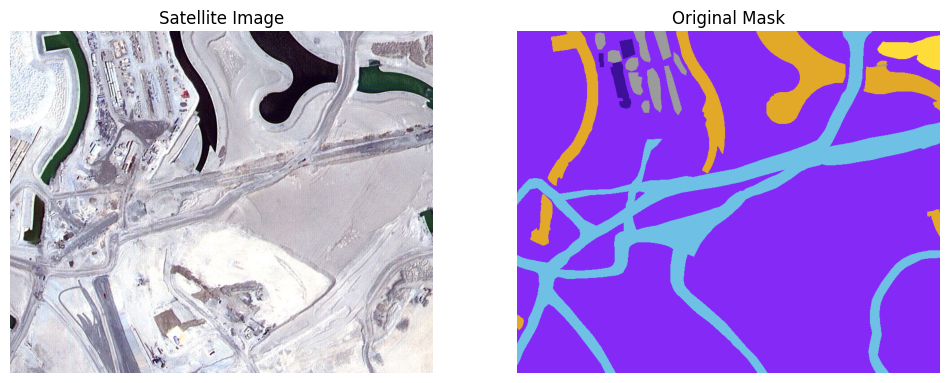

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_rgb)
plt.title("Original Mask")
plt.axis("off")

plt.show()

In [54]:
colors, counts = np.unique(
    mask_rgb.reshape(-1, 3),
    axis=0,
    return_counts=True
)

print("Number of unique colors:", len(colors))

for color, count in zip(colors, counts):

    print(
        tuple(int(x) for x in color),
        "->",
        count,
        "pixels"
    )

Number of unique colors: 6
(60, 16, 152) -> 2779 pixels
(110, 193, 228) -> 73093 pixels
(132, 41, 246) -> 388530 pixels
(155, 155, 155) -> 7920 pixels
(226, 169, 41) -> 36569 pixels
(254, 221, 58) -> 4377 pixels


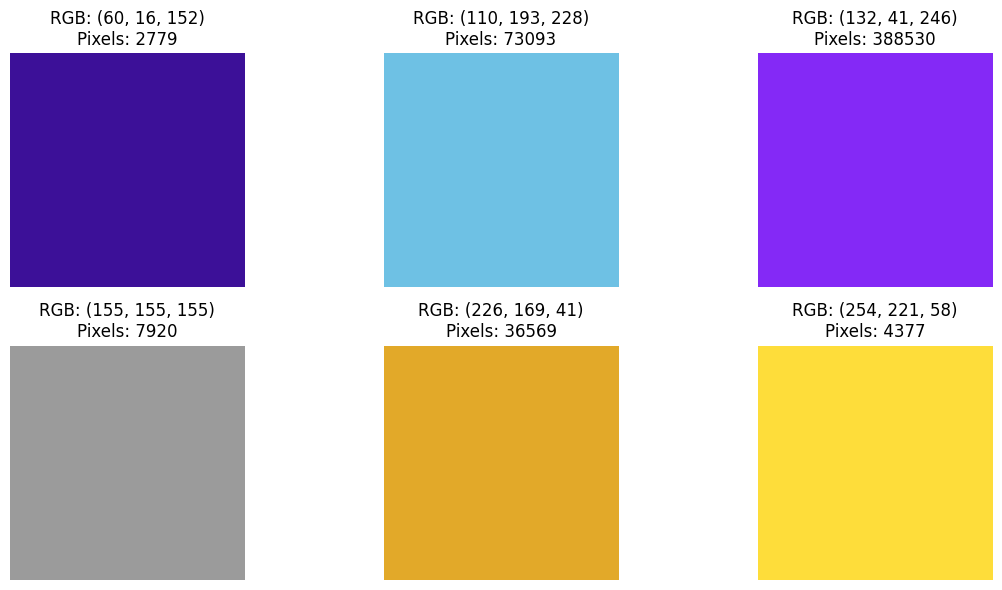

In [55]:
plt.figure(figsize=(12, 6))

for i, (color, count) in enumerate(zip(colors, counts)):

    plt.subplot(2, 3, i + 1)

    patch = np.zeros((100, 100, 3), dtype=np.uint8)
    patch[:, :] = color

    plt.imshow(patch)

    plt.title(
        f"RGB: {tuple(int(x) for x in color)}\n"
        f"Pixels: {count}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
ACTUAL_MASK_COLORS = [
    (60, 16, 152),
    (110, 193, 228),
    (132, 41, 246),
    (155, 155, 155),
    (226, 169, 41),
    (254, 221, 58)
]

NUM_CLASSES = len(ACTUAL_MASK_COLORS)

print("Number of classes:", NUM_CLASSES)

for class_id, color in enumerate(ACTUAL_MASK_COLORS):
    print(class_id, "->", color)

Number of classes: 6
0 -> (60, 16, 152)
1 -> (110, 193, 228)
2 -> (132, 41, 246)
3 -> (155, 155, 155)
4 -> (226, 169, 41)
5 -> (254, 221, 58)


In [57]:
def rgb_to_label(mask):
    label = np.zeros(
        mask.shape[:2],
        dtype=np.uint8
    )

    for class_id, color in enumerate(ACTUAL_MASK_COLORS):

        color = np.array(
            color,
            dtype=np.uint8
        )

        match = np.all(
            mask == color,
            axis=-1
        )

        label[match] = class_id

    return label

In [58]:
label = rgb_to_label(mask_rgb)

print("Unique class IDs:", np.unique(label))

for class_id, count in zip(
    *np.unique(label, return_counts=True)
):
    print(
        class_id,
        "->",
        ACTUAL_MASK_COLORS[class_id],
        ":",
        count,
        "pixels"
    )

Unique class IDs: [0 1 2 3 4 5]
0 -> (60, 16, 152) : 2779 pixels
1 -> (110, 193, 228) : 73093 pixels
2 -> (132, 41, 246) : 388530 pixels
3 -> (155, 155, 155) : 7920 pixels
4 -> (226, 169, 41) : 36569 pixels
5 -> (254, 221, 58) : 4377 pixels


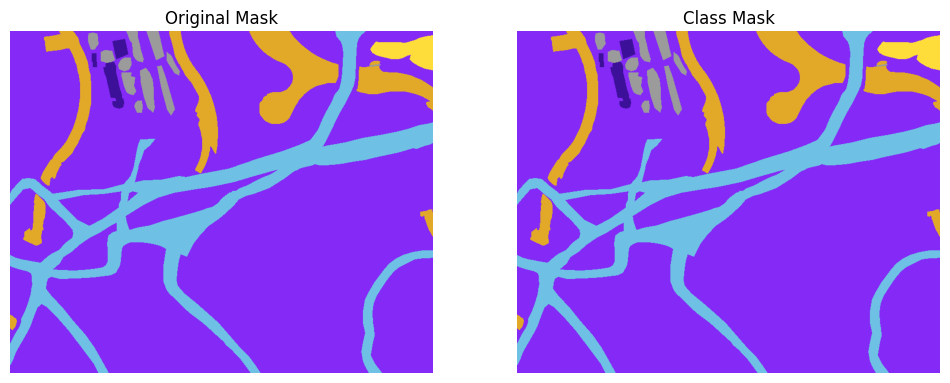

In [61]:
color_array = np.array(
    ACTUAL_MASK_COLORS,
    dtype=np.uint8
)

label_rgb = color_array[label]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mask_rgb)
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label_rgb)
plt.title("Class Mask")
plt.axis("off")

plt.show()

In [62]:
image_paths_train, image_paths_test, mask_paths_train, mask_paths_test = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.15,
    random_state=100
)

print("Training image/mask pairs:", len(image_paths_train))
print("Testing image/mask pairs :", len(image_paths_test))

Training image/mask pairs: 61
Testing image/mask pairs : 11


In [63]:
def create_patches(image, mask):

    image_patches = []
    mask_patches = []

    height = (
        image.shape[0] // IMAGE_SIZE
    ) * IMAGE_SIZE

    width = (
        image.shape[1] // IMAGE_SIZE
    ) * IMAGE_SIZE

    image = image[:height, :width]
    mask = mask[:height, :width]

    for y in range(
        0,
        height,
        IMAGE_SIZE
    ):

        for x in range(
            0,
            width,
            IMAGE_SIZE
        ):

            image_patch = image[
                y:y + IMAGE_SIZE,
                x:x + IMAGE_SIZE
            ]

            mask_patch = mask[
                y:y + IMAGE_SIZE,
                x:x + IMAGE_SIZE
            ]

            image_patches.append(
                image_patch
            )

            mask_patches.append(
                mask_patch
            )

    return image_patches, mask_patches

In [64]:
def data_generator(
    image_paths,
    mask_paths
):

    for image_path, mask_path in zip(
        image_paths,
        mask_paths
    ):

        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path)

        if image is None or mask is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.cvtColor(
            mask,
            cv2.COLOR_BGR2RGB
        )

        image = image.astype(
            np.float32
        ) / 255.0

        mask = rgb_to_label(mask)

        image_patches, mask_patches = create_patches(
            image,
            mask
        )

        for image_patch, mask_patch in zip(
            image_patches,
            mask_patches
        ):

            mask_patch = tf.keras.utils.to_categorical(
                mask_patch,
                num_classes=NUM_CLASSES
            )

            yield (
                image_patch.astype(np.float32),
                mask_patch.astype(np.float32)
            )

In [65]:
output_signature = (
    tf.TensorSpec(
        shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ),
        dtype=tf.float32
    ),

    tf.TensorSpec(
        shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            NUM_CLASSES
        ),
        dtype=tf.float32
    )
)

In [66]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(
        image_paths_train,
        mask_paths_train
    ),
    output_signature=output_signature
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(1)

In [67]:
test_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(
        image_paths_test,
        mask_paths_test
    ),
    output_signature=output_signature
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(1)

In [68]:
for images, masks in train_dataset.take(1):

    print(
        "Images shape:",
        images.shape
    )

    print(
        "Masks shape:",
        masks.shape
    )

Images shape: (2, 256, 256, 3)
Masks shape: (2, 256, 256, 6)


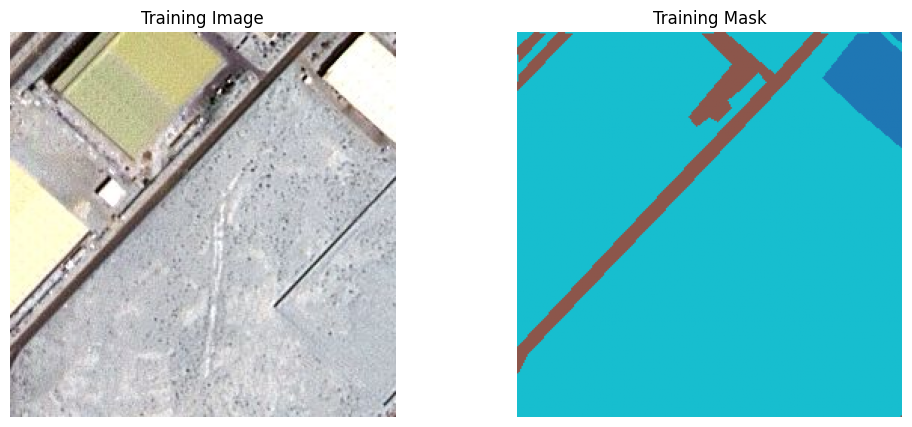

In [69]:
for images, masks in train_dataset.take(1):

    sample_image = images[0].numpy()

    sample_mask = np.argmax(
        masks[0].numpy(),
        axis=-1
    )

    break

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Training Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    sample_mask,
    cmap="tab10"
)
plt.title("Training Mask")
plt.axis("off")

plt.show()

In [70]:
class_pixel_counts = np.zeros(
    NUM_CLASSES,
    dtype=np.int64
)

for images, masks in train_dataset:

    class_ids = np.argmax(
        masks.numpy(),
        axis=-1
    )

    for class_id in range(NUM_CLASSES):

        class_pixel_counts[class_id] += np.sum(
            class_ids == class_id
        )

print("Class distribution:")

for class_id, count in enumerate(
    class_pixel_counts
):

    percentage = (
        count /
        class_pixel_counts.sum()
    ) * 100

    print(
        f"Class {class_id}: "
        f"{count} pixels "
        f"({percentage:.2f}%)"
    )

Class distribution:
Class 0: 9265599 pixels (12.91%)
Class 1: 6840991 pixels (9.53%)
Class 2: 37965974 pixels (52.91%)
Class 3: 341615 pixels (0.48%)
Class 4: 9635900 pixels (13.43%)
Class 5: 7711841 pixels (10.75%)


In [71]:
def jaccard_coef(y_true, y_pred):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3]
    )

    union = tf.reduce_sum(
        y_true + y_pred,
        axis=[1, 2, 3]
    ) - intersection

    jaccard = (
        intersection + 1e-7
    ) / (
        union + 1e-7
    )

    return tf.reduce_mean(jaccard)

In [72]:
def dice_loss(y_true, y_pred):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3]
    )

    denominator = tf.reduce_sum(
        y_true + y_pred,
        axis=[1, 2, 3]
    )

    dice = (
        2.0 * intersection + 1e-7
    ) / (
        denominator + 1e-7
    )

    return 1.0 - tf.reduce_mean(dice)

In [73]:
def categorical_focal_loss(
    y_true,
    y_pred,
    alpha=0.25,
    gamma=2.0
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    epsilon = tf.keras.backend.epsilon()

    y_pred = tf.clip_by_value(
        y_pred,
        epsilon,
        1.0 - epsilon
    )

    cross_entropy = (
        -y_true *
        tf.math.log(y_pred)
    )

    focal_factor = (
        alpha *
        tf.pow(
            1.0 - y_pred,
            gamma
        )
    )

    focal_loss = (
        focal_factor *
        cross_entropy
    )

    focal_loss = tf.reduce_sum(
        focal_loss,
        axis=-1
    )

    return tf.reduce_mean(
        focal_loss
    )

In [74]:
def total_loss(y_true, y_pred):

    return (
        dice_loss(
            y_true,
            y_pred
        )
        +
        categorical_focal_loss(
            y_true,
            y_pred
        )
    )

In [75]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    Concatenate
)

from tensorflow.keras.models import Model

In [76]:
def conv_block(
    inputs,
    filters
):

    x = Conv2D(
        filters,
        3,
        activation="relu",
        padding="same"
    )(inputs)

    x = Conv2D(
        filters,
        3,
        activation="relu",
        padding="same"
    )(x)

    return x

In [77]:
def build_unet():

    inputs = Input(
        shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        )
    )

    c1 = conv_block(
        inputs,
        16
    )

    p1 = MaxPooling2D(
        (2, 2)
    )(c1)

    c2 = conv_block(
        p1,
        32
    )

    p2 = MaxPooling2D(
        (2, 2)
    )(c2)

    c3 = conv_block(
        p2,
        64
    )

    p3 = MaxPooling2D(
        (2, 2)
    )(c3)

    c4 = conv_block(
        p3,
        128
    )

    p4 = MaxPooling2D(
        (2, 2)
    )(c4)

    c5 = conv_block(
        p4,
        256
    )

    u6 = Conv2DTranspose(
        128,
        2,
        strides=2,
        padding="same"
    )(c5)

    u6 = Concatenate()([
        u6,
        c4
    ])

    c6 = conv_block(
        u6,
        128
    )

    u7 = Conv2DTranspose(
        64,
        2,
        strides=2,
        padding="same"
    )(c6)

    u7 = Concatenate()([
        u7,
        c3
    ])

    c7 = conv_block(
        u7,
        64
    )

    u8 = Conv2DTranspose(
        32,
        2,
        strides=2,
        padding="same"
    )(c7)

    u8 = Concatenate()([
        u8,
        c2
    ])

    c8 = conv_block(
        u8,
        32
    )

    u9 = Conv2DTranspose(
        16,
        2,
        strides=2,
        padding="same"
    )(c8)

    u9 = Concatenate()([
        u9,
        c1
    ])

    c9 = conv_block(
        u9,
        16
    )

    outputs = Conv2D(
        NUM_CLASSES,
        1,
        activation="softmax"
    )(c9)

    return Model(
        inputs,
        outputs
    )

In [78]:
model = build_unet()

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_21[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_23[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_25[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_7[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_27[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │    131,200 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 1,941,190 (7.41 MB)

 Trainable params: 1,941,190 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=total_loss,
    metrics=[
        "accuracy",
        jaccard_coef
    ]
)

In [80]:
history_1 = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=1,
    verbose=1
)

548/548 ━━━━━━━━━━━━━━━━━━━━ 56s 75ms/step - accuracy: 0.5398 - jaccard_coef: 0.3317 - loss: 0.7877 - val_accuracy: 0.6391 - val_jaccard_coef: 0.4807 - val_loss: 0.5551


In [81]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    verbose=1
)

Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.6392 - jaccard_coef: 0.4743 - loss: 0.5957 - val_accuracy: 0.6555 - val_jaccard_coef: 0.5172 - val_loss: 0.5330
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.6578 - jaccard_coef: 0.4936 - loss: 0.5589 - val_accuracy: 0.7025 - val_jaccard_coef: 0.5288 - val_loss: 0.4916
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.6753 - jaccard_coef: 0.5096 - loss: 0.5342 - val_accuracy: 0.7240 - val_jaccard_coef: 0.5636 - val_loss: 0.4531
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.7003 - jaccard_coef: 0.5281 - loss: 0.5063 - val_accuracy: 0.7466 - val_jaccard_coef: 0.5820 - val_loss: 0.4359
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.7294 - jaccard_coef: 0.5482 - loss: 0.4776 - val_accuracy: 0.7665 - val_jaccard_coef: 0.6048 - val_loss: 0.4138
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.7538 - jaccard_coef: 0.5665 - lo

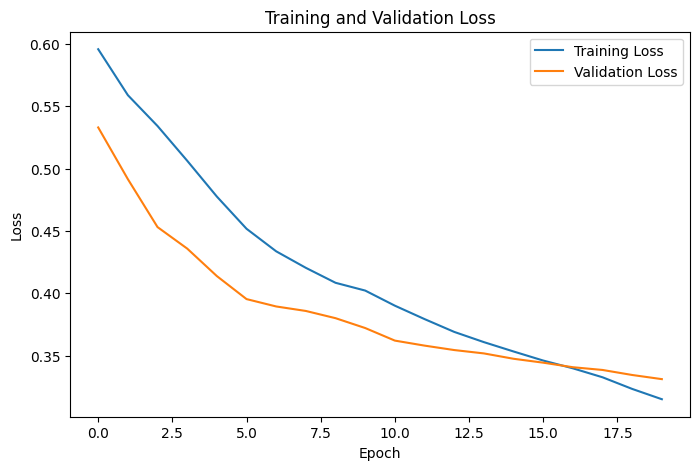

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

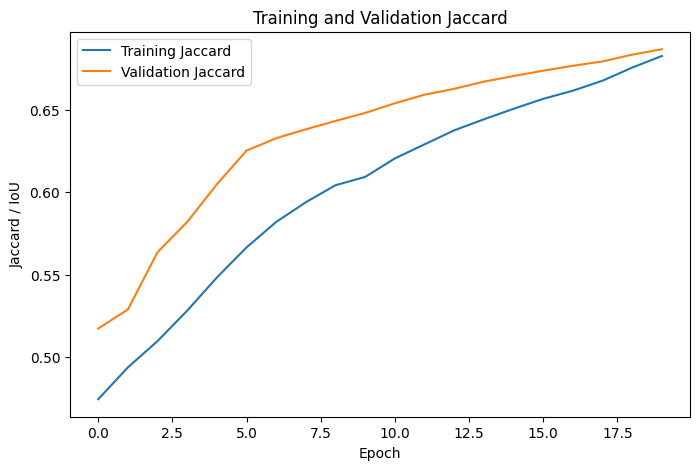

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["jaccard_coef"],
    label="Training Jaccard"
)

plt.plot(
    history.history["val_jaccard_coef"],
    label="Validation Jaccard"
)

plt.title("Training and Validation Jaccard")
plt.xlabel("Epoch")
plt.ylabel("Jaccard / IoU")
plt.legend()

plt.show()

In [84]:
for images, masks in test_dataset.take(1):

    sample_image = images[0].numpy()

    sample_mask = masks[0].numpy()

    break

true_mask = np.argmax(
    sample_mask,
    axis=-1
)

print(
    "Image shape:",
    sample_image.shape
)

print(
    "Mask shape:",
    sample_mask.shape
)

print(
    "True classes:",
    np.unique(true_mask)
)

Image shape: (256, 256, 3)
Mask shape: (256, 256, 6)
True classes: [0 1 2]


In [85]:
prediction = model.predict(
    sample_image[np.newaxis, ...],
    verbose=0
)

predicted_mask = np.argmax(
    prediction[0],
    axis=-1
)

print(
    "True classes:",
    np.unique(true_mask)
)

print(
    "Predicted classes:",
    np.unique(predicted_mask)
)

True classes: [0 1 2]
Predicted classes: [0 1 2 4 5]


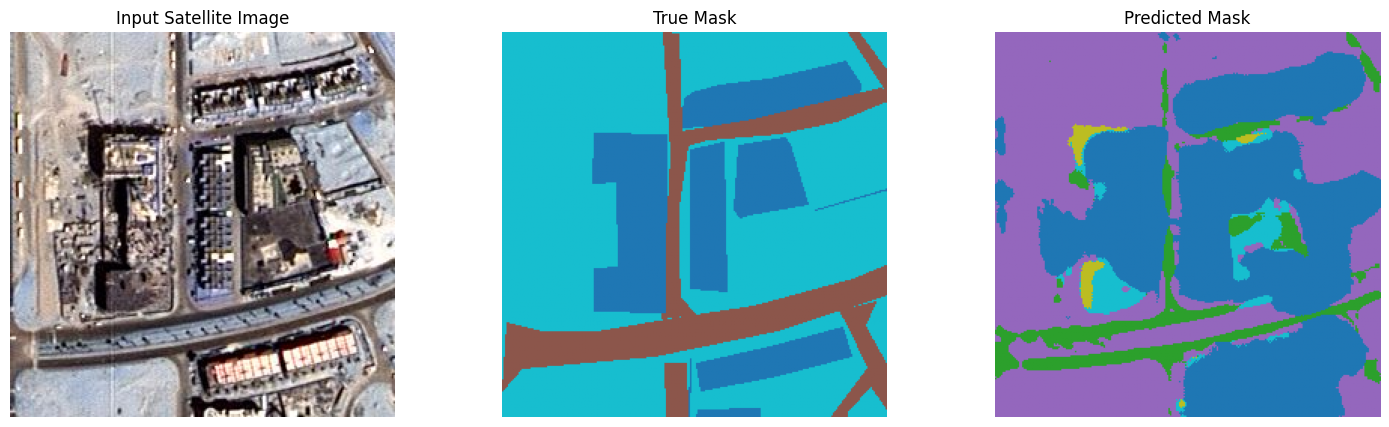

In [86]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Input Satellite Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    true_mask,
    cmap="tab10"
)
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    predicted_mask,
    cmap="tab10"
)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [87]:
color_array = np.array(
    ACTUAL_MASK_COLORS,
    dtype=np.uint8
)

predicted_rgb = color_array[
    predicted_mask
]

true_rgb = color_array[
    true_mask
]

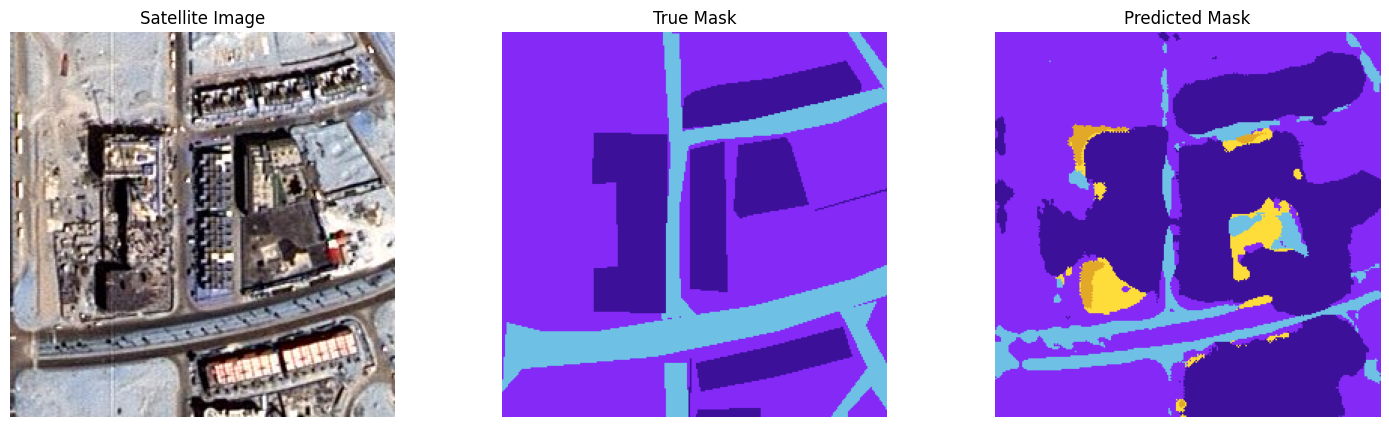

In [98]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_rgb)
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_rgb)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [89]:
conv_layers = [
    layer
    for layer in model.layers
    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    )
]

print(
    "Number of Conv2D layers:",
    len(conv_layers)
)

Number of Conv2D layers: 19


In [90]:
activation_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        layer.output
        for layer in conv_layers
    ]
)

activations = activation_model.predict(
    sample_image[np.newaxis, ...],
    verbose=0
)

print(
    "Number of activation maps:",
    len(activations)
)

Number of activation maps: 19


Activation shape: (1, 256, 256, 16)


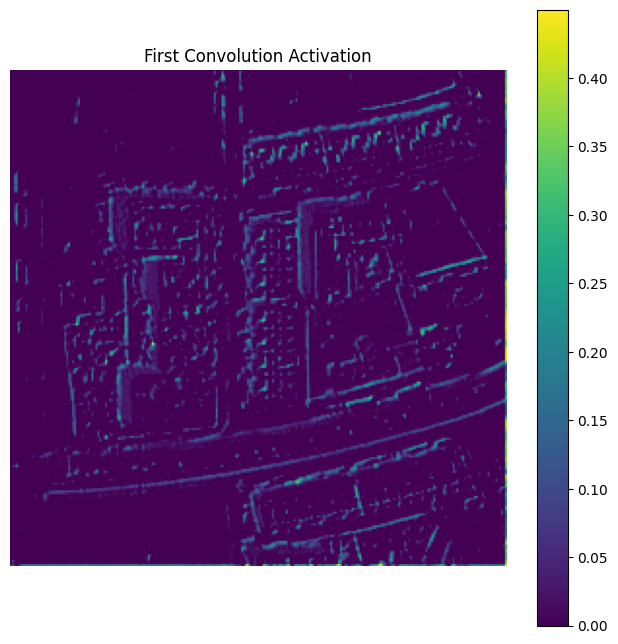

In [91]:
activation = activations[0]

print(
    "Activation shape:",
    activation.shape
)

feature_map = activation[
    0, :, :, 0
]

plt.figure(figsize=(8, 8))

plt.imshow(
    feature_map,
    cmap="viridis"
)

plt.colorbar()

plt.title(
    "First Convolution Activation"
)

plt.axis("off")

plt.show()

In [92]:
image_tensor = tf.convert_to_tensor(
    sample_image[np.newaxis, ...],
    dtype=tf.float32
)

with tf.GradientTape() as tape:

    tape.watch(image_tensor)

    prediction = model(
        image_tensor,
        training=False
    )

    class_score = tf.reduce_max(
        prediction[0],
        axis=-1
    )

    class_score = tf.reduce_mean(
        class_score
    )

gradients = tape.gradient(
    class_score,
    image_tensor
)

gradients = gradients[0]

heatmap = tf.reduce_mean(
    tf.abs(gradients),
    axis=-1
).numpy()

heatmap = (
    heatmap - heatmap.min()
) / (
    heatmap.max()
    - heatmap.min()
    + 1e-8
)

print(
    "Heatmap shape:",
    heatmap.shape
)

Heatmap shape: (256, 256)


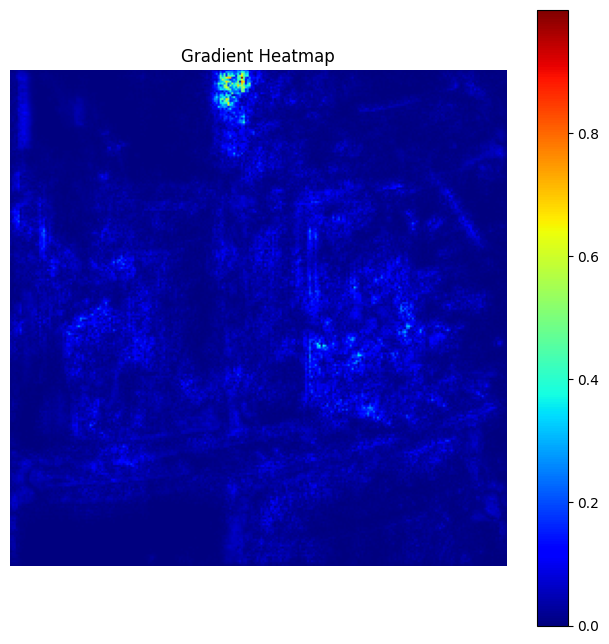

In [93]:
plt.figure(figsize=(8, 8))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title(
    "Gradient Heatmap"
)

plt.axis("off")

plt.show()

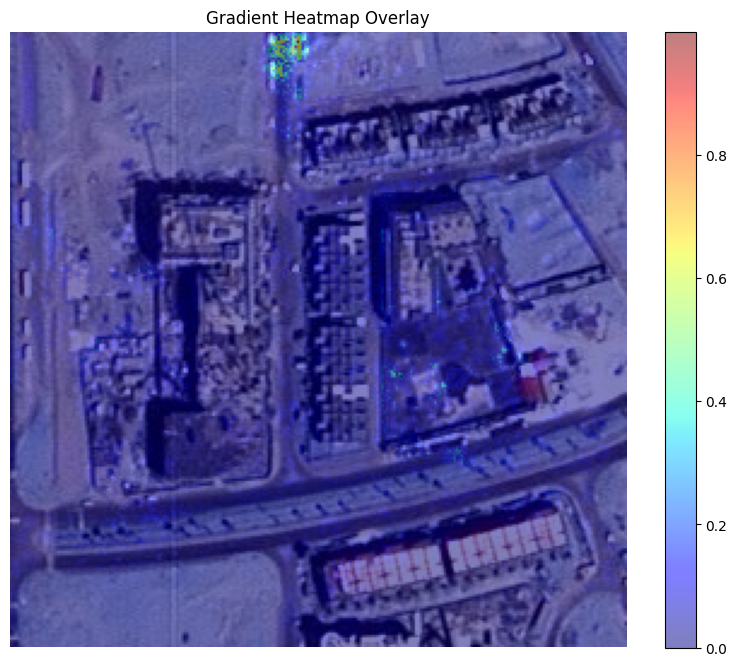

In [94]:
plt.figure(figsize=(10, 8))

plt.imshow(
    sample_image
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Gradient Heatmap Overlay"
)

plt.axis("off")

plt.colorbar()

plt.show()